## Khởi tạo

In [1]:
import sys,os
__script_path=os.path.abspath(globals().get('__file__','.'))
__script_dir = os.path.dirname(__script_path)
root_dir = os.path.abspath(f'{__script_dir}/..')
print(root_dir)
for lib in [root_dir][::-1]:
    if lib in sys.path:
        sys.path.remove(lib)
    sys.path.insert(0,lib)


c:\Users\PC\Data\WDM-AI-TEMIS


In [ ]:
from configs.config import *
from libs.common import *
from utils.format_utils import *
from src.WDMParser.WDMParser import full_pipeline
from dotenv import load_dotenv, find_dotenv
from utils.hybridgraphrag_utils import HybridGraphRAG
from utils.rag_evaluation import run_ragas_eval, plot_experiment_comparison
load_dotenv(find_dotenv())

c:/Users/Admin/Data/WDM-AI-TEMIS
root_dir: c:/Users/Admin/Data/WDM-AI-TEMIS
c:/Users/Admin/Data/WDM-AI-TEMIS/data


c:\Users\Admin\Data\WDM-AI-TEMIS\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-23 21:07:29.755 | WARNING  | fastembed.embedding:<module>:7 - DefaultEmbedding, FlagEmbedding, JinaEmbedding are deprecated.Use from fastembed import TextEmbedding instead.


True

In [4]:
os.makedirs(exps_dir, exist_ok=True)

In [5]:
mongo_uri = os.getenv('MONGO_URI')
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
QUOTIENTAI = os.getenv('QuotientAI')
collection = "kyanon_digital"

# mongo_client = get_mongo_client(mongo_uri)
# db = mongo_client['Kyanon']
# collection = db['RAG']
collection_name = "kyanon_digital"
QUOTIENT_API_KEY = os.getenv('QUOTIENT_API_KEY')

In [6]:
exps_dir

'c:/Users/PC/Data/WDM-AI-TEMIS/exps'

In [7]:
import torch
torch.cuda.is_available()

True

In [9]:
from fastembed.embedding import TextEmbedding

data=pd.DataFrame(TextEmbedding.list_supported_models())
data

,model,sources,model_file,description,license,size_in_GB,additional_files,dim,tasks
0,BAAI/bge-base-en,"{'hf': 'Qdrant/fast-bge-base-en', 'url': 'http...",model_optimized.onnx,"Text embeddings, Unimodal (text), English, 512...",mit,0.420,[],768,{}
1,BAAI/bge-base-en-v1.5,"{'hf': 'qdrant/bge-base-en-v1.5-onnx-q', 'url'...",model_optimized.onnx,"Text embeddings, Unimodal (text), English, 512...",mit,0.210,[],768,{}
2,BAAI/bge-large-en-v1.5,"{'hf': 'qdrant/bge-large-en-v1.5-onnx', 'url':...",model.onnx,"Text embeddings, Unimodal (text), English, 512...",mit,1.200,[],1024,{}
3,BAAI/bge-small-en,"{'hf': 'Qdrant/bge-small-en', 'url': 'https://...",model_optimized.onnx,"Text embeddings, Unimodal (text), English, 512...",mit,0.130,[],384,{}
4,BAAI/bge-small-en-v1.5,"{'hf': 'qdrant/bge-small-en-v1.5-onnx-q', 'url...",model_optimized.onnx,"Text embeddings, Unimodal (text), English, 512...",mit,0.067,[],384,{}
5,BAAI/bge-small-zh-v1.5,"{'hf': 'Qdrant/bge-small-zh-v1.5', 'url': 'htt...",model_optimized.onnx,"Text embeddings, Unimodal (text), Chinese, 512...",mit,0.090,[],512,{}
6,mixedbread-ai/mxbai-embed-large-v1,"{'hf': 'mixedbread-ai/mxbai-embed-large-v1', '...",onnx/model.onnx,"Text embeddings, Unimodal (text), English, 512...",apache-2.0,0.640,[],1024,{}
7,snowflake/snowflake-arctic-embed-xs,"{'hf': 'snowflake/snowflake-arctic-embed-xs', ...",onnx/model.onnx,"Text embeddings, Unimodal (text), English, 512...",apache-2.0,0.090,[],384,{}
8,snowflake/snowflake-arctic-embed-s,"{'hf': 'snowflake/snowflake-arctic-embed-s', '...",onnx/model.onnx,"Text embeddings, Unimodal (text), English, 512...",apache-2.0,0.130,[],384,{}
9,snowflake/snowflake-arctic-embed-m,"{'hf': 'Snowflake/snowflake-arctic-embed-m', '...",onnx/model.onnx,"Text embeddings, Unimodal (text), English, 512...",apache-2.0,0.430,[],768,{}


In [10]:
data.model.unique()

array(['BAAI/bge-base-en', 'BAAI/bge-base-en-v1.5',
       'BAAI/bge-large-en-v1.5', 'BAAI/bge-small-en',
       'BAAI/bge-small-en-v1.5', 'BAAI/bge-small-zh-v1.5',
       'mixedbread-ai/mxbai-embed-large-v1',
       'snowflake/snowflake-arctic-embed-xs',
       'snowflake/snowflake-arctic-embed-s',
       'snowflake/snowflake-arctic-embed-m',
       'snowflake/snowflake-arctic-embed-m-long',
       'snowflake/snowflake-arctic-embed-l', 'jinaai/jina-clip-v1',
       'Qdrant/clip-ViT-B-32-text',
       'sentence-transformers/all-MiniLM-L6-v2',
       'jinaai/jina-embeddings-v2-base-en',
       'jinaai/jina-embeddings-v2-small-en',
       'jinaai/jina-embeddings-v2-base-de',
       'jinaai/jina-embeddings-v2-base-code',
       'jinaai/jina-embeddings-v2-base-zh',
       'jinaai/jina-embeddings-v2-base-es', 'thenlper/gte-base',
       'thenlper/gte-large', 'nomic-ai/nomic-embed-text-v1.5',
       'nomic-ai/nomic-embed-text-v1.5-Q', 'nomic-ai/nomic-embed-text-v1',
       'sentence-transfor

In [13]:
import requests
import json

def summary_fn(prompt):
    """
    Gửi prompt đến Ollama và nhận về một đoạn phản hồi hoàn chỉnh.
    
    Tham số:
        prompt (str): Câu hỏi hoặc yêu cầu bạn muốn gửi đến mô hình.

    Trả về:
        str: Phản hồi hoàn chỉnh từ mô hình.
    """
    response = requests.post(
  url="https://openrouter.ai/api/v1/chat/completions",
  headers={
    "Authorization": f"Bearer {os.getenv('API_OPENROUTE')}",
    "Content-Type": "application/json",
  },
  data=json.dumps({
    "model": "mistralai/devstral-small:free",
    "messages": [
      {
        "role": "user",
        "content": [
          {
            "type": "text",
            "text": f"""
    You are given a single table fragment extracted from a PDF document using OCR. This fragment may be part of a larger table that was split across multiple pages due to formatting or page layout.
    Your task is to generate a detailed and comprehensive summary of the content in this table fragment.
    The summary should clearly describe:
        The main subject or topic of the table
        Key columns and their meanings
        Important patterns, trends, or observations in the data
        Any notable values or anomalies
        Contextual information needed to understand the data
    Write the summary in 1–3 full sentences , using clear and precise language.
    If applicable, mention that this fragment appears to be part of a larger table, and include any inferred continuity from the data.
    {prompt}
"""
          }
        ]
      }
    ],
    
  })
)

    return response.json().get("choices", [{}])[0].get("message", {}).get("content", "")

In [14]:
def extract_all_table(folder_path, output_json_filename="./final_tables.json"):
    all_results = {}

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".pdf"):
            pdf_path = os.path.join(folder_path, filename)
            json_result = full_pipeline(source_path=pdf_path, verbose=1)

            for key, value_list in json_result.items():
                if key not in all_results:
                    all_results[key] = []
                all_results[key].extend(value_list) 

    try:
        output_path = os.path.join(folder_path, output_json_filename)
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(all_results, f, ensure_ascii=False, indent=4)
        print(f"✅ Đã lưu toàn bộ kết quả vào: {output_json_filename}")
    except Exception as e:
        print(f"[LỖI] Không thể ghi file JSON tổng hợp: {e}")

    return all_results

In [15]:
# table_results = extract_all_table(folder_path=f"{data_dir}/pdf/")

In [ ]:
# table_results

In [16]:
from collections import defaultdict
from langchain.docstore.document import Document as LangchainDocument

qa_path = f"{data_dir}/QA_tables/fixed_label_QA.json"

def extract_unique_tables_from_qa():
    """
    Trích xuất các table unique từ file fixed_.json và tạo LangChainDocument
    """
    # Đọc file QA
    with open(qa_path, 'r', encoding='utf-8') as f:
        qa_data = json.load(f)
    
    # Dictionary để lưu trữ table unique
    # Key: (source, table_idx)
    # Value: table information
    unique_tables = {}
    
    # Duyệt qua tất cả các câu hỏi để tìm table unique
    for qa_item in qa_data:
        source = qa_item["source"]
        table_idx = qa_item["table_idx"] 
        page_numbers = qa_item["page_numbers"]
        context = qa_item["context"]
        
        # Tạo key unique cho table
        table_key = (source, table_idx)
        
        # Nếu chưa có table này trong dictionary, thêm vào
        if table_key not in unique_tables:
            unique_tables[table_key] = {
                "source": source,
                "table_idx": table_idx,
                "page_numbers": page_numbers,
                "table_content": context
            }
        else:
            # Cập nhật page_numbers nếu có thêm trang mới
            existing_pages = set(unique_tables[table_key]["page_numbers"])
            new_pages = set(page_numbers)
            all_pages = sorted(list(existing_pages.union(new_pages)))
            unique_tables[table_key]["page_numbers"] = all_pages
    
    # Tạo danh sách LangChainDocument
    table_documents = []
    
    for table_key, table_info in unique_tables.items():
        table_document = LangchainDocument(
            page_content=table_info["table_content"],
            metadata={
                "source": table_info["source"],
                "page_numbers": table_info["page_numbers"],
                "is_table": True,
                "source_table_idx": table_info["table_idx"]
            }
        )
        table_documents.append(table_document)
    
    return table_documents

def get_tables_statistics():
    """
    Thống kê về các table unique được tìm thấy
    """
    with open(qa_path, 'r', encoding='utf-8') as f:
        qa_data = json.load(f)
    
    # Thống kê theo source
    source_stats = defaultdict(set)
    total_qa_pairs = len(qa_data)
    
    for qa_item in qa_data:
        source = qa_item["source"]
        table_idx = qa_item["table_idx"]
        source_stats[source].add(table_idx)
    
    print(f"Tổng số câu hỏi-trả lời: {total_qa_pairs}")
    print(f"Số file/source unique: {len(source_stats)}")
    
    total_unique_tables = sum(len(table_indices) for table_indices in source_stats.values())
    print(f"Tổng số table unique: {total_unique_tables}")
    
    print("\nThống kê theo source:")
    for source, table_indices in source_stats.items():
        print(f"  {source}: {len(table_indices)} table(s) - table_idx: {sorted(list(table_indices))}")
    
    return source_stats

In [17]:
# def summarize_table():
#     tables = []
#     tables_sources = json.load(open(f"{data_dir}/QA_tables/pdf/final_tables.json", 'r', encoding='utf-8'))
#     sources = list(tables_sources.keys())
#     for source in sources:
#         for table in tables_sources[source]:
#             table_document = LangchainDocument(
#                 # summary =summary_fn(table['table_content']),
#                 page_content=table['table_content'],
#                 metadata={
#                     "source": source,
#                     "page_numbers": table['page_numbers'],
#                     "is_table": True,
#                     "source_table_idx": table['table_idx']
#                 }
#             )
#             tables.append(table_document)
#     return tables

In [18]:
stats = get_tables_statistics()

Tổng số câu hỏi-trả lời: 845
Số file/source unique: 37
Tổng số table unique: 306

Thống kê theo source:
  0c92f65db928c431023f59603039aa1e.pdf: 30 table(s) - table_idx: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
  table 1: 10 table(s) - table_idx: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  table_1.pdf : 5 table(s) - table_idx: [0, 1, 2, 3, 4]
  table1: 2 table(s) - table_idx: [0, 1]
  table data : 6 table(s) - table_idx: [0, 1, 2, 3, 4, 5]
  table: 6 table(s) - table_idx: [0, 1, 2, 3, 4, 5]
  table_data: 2 table(s) - table_idx: [0, 1]
  0f2eac764c8d04d8d13d8a999342d106.pdf: 20 table(s) - table_idx: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  2c98e99a08ec5392d50e60370d871319.pdf: 6 table(s) - table_idx: [0, 1, 2, 3, 4, 5]
  2d64938a8d3e12dbb709f760ecd53e14.pdf: 1 table(s) - table_idx: [0]
  2e1b34aa28e718f66bfe600045ed7387.pdf: 8 table(s) - table_idx: [0, 1, 2, 3, 4, 5, 6, 7]
  table_data.pdf: 5 table

In [23]:
import pymupdf
def get_detail_chunks(pdf_path):
    doc = pymupdf.open(pdf_path)
    source = os.path.splitext(os.path.basename(pdf_path))[0]

    page_documents = []
    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        
        for tab in page.find_tables(strategy = "text"):
            # process the content of table 'tab'
            page.add_redact_annot(tab.bbox)  # wrap table in a redaction annotation
                
        page.apply_redactions()
        
        text = page.get_text().strip()
        if not text:
            continue

        page_document = LangchainDocument(
            page_content=text,
            metadata={
                "source": source,
                "page_numbers": [page_num + 1], 
                "is_table": False
            }
        )
        page_documents.append(page_document)

    doc.close()
    return page_documents

In [24]:
def process_all_pdfs_in_folder(folder_path):
    all_page_documents = []
    all_table_documents = []

    table_docs = extract_unique_tables_from_qa()
    all_table_documents.extend(table_docs)

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".pdf"):
            pdf_path = os.path.join(folder_path, filename)
            print(f"\n>>> Đang xử lý: {pdf_path}")
            page_docs = get_detail_chunks(pdf_path)
            all_page_documents.extend(page_docs)

    return all_page_documents, all_table_documents

In [25]:
data_dir

'c:/Users/PC/Data/WDM-AI-TEMIS/data'

In [26]:
all_page_documents, all_table_documents =process_all_pdfs_in_folder(f"{data_dir}/QA_tables/pdf/")



>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/0c92f65db928c431023f59603039aa1e.pdf

>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/0ed7f2ecfd607a42c745b0889e500ecf.pdf

>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/0f2eac764c8d04d8d13d8a999342d106.pdf

>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/2c98e99a08ec5392d50e60370d871319.pdf

>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/2d64938a8d3e12dbb709f760ecd53e14.pdf

>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/2e1b34aa28e718f66bfe600045ed7387.pdf

>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/3e8e568ec576f0189cee0b6032720054.pdf

>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/4bd9336ffdb1593d71a919b7e7d68995.pdf

>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/4f37fc393094547bbbe030cecedf9a3b.pdf

>>> Đang xử lý: c:/Users/PC/Data/WDM-AI-TEMIS/data/QA_tables/pdf/5b85b2a

In [27]:
print(len(all_page_documents))
print(len(all_table_documents))

535
306


## Evaluation

In [28]:
import json

with open(f"{data_dir}/QA_tables/fixed_label_QA.json", "r", encoding="utf-8") as f:
    eval_data = json.load(f)

eval_df = pd.DataFrame(eval_data)
eval_df.head()



,id,source,page_numbers,table_idx,question,answer,context
0,qa_1_001,0c92f65db928c431023f59603039aa1e.pdf,[2],0,What does the symbol '‡' indicate?,Indicates the winner,| Symbol | Description |\...
1,qa_1_002,0c92f65db928c431023f59603039aa1e.pdf,[2],0,What does the symbol '†' indicate?,Indicates a posthumous nominee,| Symbol | Description |\...
2,qa_1_003,0c92f65db928c431023f59603039aa1e.pdf,[2],0,What is the column header for 'Indicates the w...,Description,| Symbol | Description |\...
3,qa_1_004,0c92f65db928c431023f59603039aa1e.pdf,[2],0,What is the column header for '‡'?,Symbol,| Symbol | Description |\...
4,qa_1_005,0c92f65db928c431023f59603039aa1e.pdf,[2],0,List all symbols in the table.,"‡, †",| Symbol | Description |\...


In [29]:
len(eval_df)

845

In [30]:
# from langchain_google_vertexai import ChatVertexAI

In [31]:
# from google.oauth2 import service_account

# credentials_path = "C:/Users/PC/Data/WDM-AI-TEMIS/gdsc2025-74596a254ab4.json"

# credentials = service_account.Credentials.from_service_account_file(credentials_path)

In [32]:
# structured_llm = ChatVertexAI(model="gemini-2.0-flash", temperature=0)


In [33]:
# generate_model_output('xin chào', 'hello')

In [34]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
os.environ["OPENAI_API_KEY"] = os.getenv('OPENAI_API_KEY')
evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))

In [35]:
from ragas.evaluation import Dataset
from ragas.evaluation import evaluate


In [36]:
from huggingface_hub import login

api_token = os.getenv('HUGGINGE_FACE_TOKEN') 
login(api_token)


## Experiment

### **Experiment 1:**

We will be starting off with the following specifications:
- **Embeddings: `bge-small-en`**
- **Chunk size: `512`**
- **Chunk overlap: `64`**
- **Number of docs: `3`**
- **Language model: `Mistral-7B-Instruct`**

In [ ]:
chunk_size = 512
chunk_overlap = 128
embedding_model_name = "BAAI/bge-base-en"
num_docs = 7
chunk_type = "character"

COLLECTION_NAME = f"experiment_{chunk_size}_{chunk_overlap}_{embedding_model_name.split('/')[1]}_{chunk_type}"
exp2 = HybridGraphRAG()
exp2.add_documents(
              collection_name=COLLECTION_NAME,
              documents=all_page_documents,
              tables=all_table_documents,
              chunk_type=chunk_type,
              chunk_size=chunk_size,
              chunk_overlap=chunk_overlap,
              embedding_model_name=embedding_model_name)

In [62]:
experiment_2 = run_ragas_eval(eval_df,
                        collection_name=COLLECTION_NAME,
                        doc_retrieval_function=exp2.get_documents,
                        num_docs=num_docs,
                        embedding_model_name=embedding_model_name,
                        path=f"{exps_dir}/{COLLECTION_NAME}_{num_docs}_gemma.csv")

Running Context Retrieve...
Running Oputput Generate...
Running RAGAS evaluation...


Evaluating:   0%|          | 0/1690 [00:00<?, ?it/s]

Evaluation completed. Results saved to c:/Users/PC/CODE/WDM-AI-TEMIS/exps/experiment_512_128_bge-base-en_character_7_gemma.csv


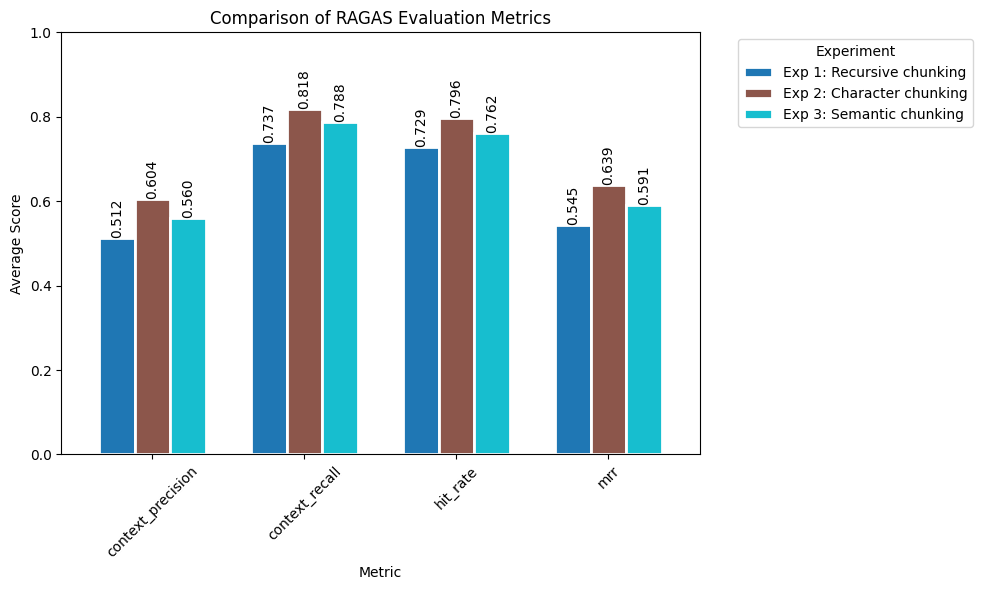

In [65]:
experiment_names = [
    "Exp 1: Recursive chunking",
    "Exp 2: Character chunking",
    "Exp 3: Semantic chunking",
]
metrics_to_plot = ["context_precision", "context_recall", "hit_rate", "mrr"]

plot_experiment_comparison([experiment_1, experiment_2, experiment_3], experiment_names, metrics_to_plot)